# Pathview Plus: deep bug checks

**Audit date:** August 10, 2026  
**Pathview Plus commit:** `07aee813375347bcc933ad21b4aed561dd7cd3bf`

This notebook is the visual, beginner-friendly version of the audit. It does
not change Pathview Plus. It reads the saved evidence produced by the strict
test suite and explains what the results mean.

### How to read the labels

- **PASS** means the tested behavior worked.
- **KNOWN_BUG** means a strict expected behavior failed in a repeatable way.
- **FEATURE_GAP** means a public feature is present in the interface or
  description but is not fully connected yet.
- A high count does **not** mean every finding is equally serious. Several are
  small edge cases. The priority list separates the release-blocking items.

In [1]:
from pathlib import Path
import csv
import json
from IPython.display import Image, SVG, display

ROOT = Path.cwd()
if ROOT.name != "pathveiw bug checks":
    candidates = [ROOT / "pathveiw bug checks", ROOT.parent / "pathveiw bug checks"]
    ROOT = next((item for item in candidates if item.exists()), ROOT)

RESULTS = ROOT / "results"
summary = json.loads((RESULTS / "summary.json").read_text())
bugs = json.loads((ROOT / "BUGS.json").read_text())
environment = json.loads((RESULTS / "environment.json").read_text())
official = json.loads(
    (RESULTS / "evidence" / "official-hsa04110" / "summary.json").read_text()
)

print("Audit folder:", ROOT)
print("Python:", environment["python"].split()[0])
print("Pathview distribution:", environment["pathview_distribution_version"])
print("Pathview runtime:", environment["pathview_runtime_version"])
print("Commit:", environment["pathview_commit"])

Audit folder: /Users/summermalik/Desktop/PATHVIEW-MARKDOWN/pathveiw bug checks
Python: 3.14.3
Pathview distribution: 2.0.2
Pathview runtime: 2.0.0
Commit: 07aee813375347bcc933ad21b4aed561dd7cd3bf


## 1. Overall result

The audit intentionally checks both normal workflows and difficult inputs.
Known findings are represented by strict expected-failure tests, so they are
visible and reproducible without making the whole suite look broken. An
**unexpected failure count of zero** means the evidence was generated cleanly.

In [2]:
print(f"Total test cases:       {summary['total_test_cases']}")
for label, count in summary["status_counts"].items():
    print(f"{label:22} {count}")
print(f"Unique bug IDs:         {summary['unique_confirmed_bug_ids']}")
print(f"Unique feature gaps:    {summary['unique_feature_gap_ids']}")
print(f"Unexpected failures:    {summary['unexpected_failures']}")

Total test cases:       239
FEATURE_GAP            7
KNOWN_BUG              89
PASS                   143
Unique bug IDs:         79
Unique feature gaps:    7
Unexpected failures:    0


## 2. What definitely worked

The most important positive result is that the core cached KEGG pathway can
render one, two, and three conditions. The node states are ordered left to
right. The suite also passed all public imports, ordinary KGML parsing,
standard numeric color clipping, common aggregation methods, ordinary SVG XML,
explicit PDF output, and controlled CLI input loading.

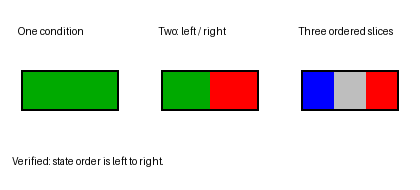

In [3]:
display(Image(filename=str(RESULTS / "evidence" / "01-state-splits.png")))

## 3. Frozen official pathway test

The audit reused the frozen official `hsa04110` KGML and PNG files already in
the project. This prevents a website outage or a future pathway revision from
changing the input in the middle of the comparison.

In [4]:
print("Input image dimensions:", tuple(official["input_dimensions"]))
print("Parsed KGML nodes:", official["parsed_nodes"])
print("Parsed KGML relations:", official["parsed_relations"])
print("Parsed KGML reactions:", official["parsed_reactions"])
print()
for output in official["png_outputs"]:
    print(
        f"{output['states']} state(s): {output['file']} | "
        f"dimensions={tuple(output['dimensions'])} | "
        f"controlled non-null rows={output['non_null_gene_values']}"
    )

Input image dimensions: (1039, 801)
Parsed KGML nodes: 115
Parsed KGML relations: 79
Parsed KGML reactions: 0

1 state(s): hsa04110.one-state.png | dimensions=(835, 646) | controlled non-null rows=3
2 state(s): hsa04110.half-and-half.png | dimensions=(835, 646) | controlled non-null rows=3
3 state(s): hsa04110.three-state.png | dimensions=(835, 646) | controlled non-null rows=3


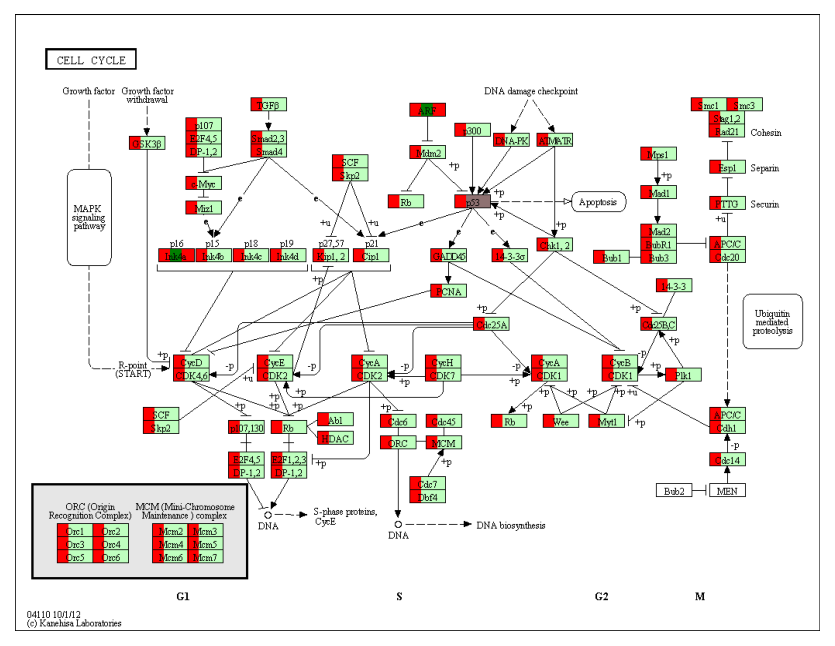

In [5]:
display(
    Image(
        filename=str(
            RESULTS / "evidence" / "official-hsa04110" / "hsa04110.half-and-half.png"
        )
    )
)

## 4. A visual example of a real rendering issue

Genes and compounds do not currently use the same vertical coordinate rule.
In the controlled image below, both receive input `y=30`. The green gene stays
near row 30, but the red compound appears near `image height - 30`. The test
also confirms that the compound width is treated as a radius and its height is
ignored. This should be fixed before relying on compound overlays.

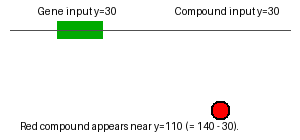

In [6]:
display(
    Image(
        filename=str(
            RESULTS / "evidence" / "02-compound-coordinate-reproduction.png"
        )
    )
)

## 5. Highest-priority release work

These are the items that most affect an ordinary user or the scientific
meaning of a produced figure. Smaller validation and edge-case findings remain
in `BUGS.json` and `TECHNICAL-FINDINGS.md`.

In [7]:
p1 = [item for item in bugs["findings"] if item["priority"] == "P1"]
for item in p1:
    print(f"{item['id']}: {item['summary']}")

PV-BUG-004: cached files cannot bypass live species lookup
PV-BUG-006: map_null=False does not remove unmapped rows when a data table exists
PV-BUG-008: core returns dict while documented highlighting requires PathwayResult
PV-BUG-009: mapped node table drops the exploded kegg_names identifier
PV-BUG-012: group aggregation UDF receives scalar elements under current Polars
PV-BUG-023: parser locates a namespaced map but searches its glyphs/arcs without namespace
PV-BUG-029: compound y coordinates are flipped while gene y coordinates are effectively not
PV-BUG-030: compound KGML width is treated as radius instead of diameter
PV-BUG-034: bbox_inches='tight' crops/rescales native output instead of preserving KEGG pixels
PV-BUG-038: graph/PDF renderer uses only the first experiment color
PV-BUG-039: highlights flip y but native gene painting does not, so borders miss noncentral nodes
PV-BUG-045: duplicated phantom/repeated Catmull-Rom points cause zero denominators and NaNs
PV-BUG-052: CLI 

### Plain-English summary of the P1 group

1. **KEGG PNG gene overlays work**, including the requested half-and-half
   beginning example.
2. **Compound placement and size need correction** before compound or
   multi-omics figures are trusted.
3. **SVG and PDF are not complete pathway diagrams yet** because relations are
   omitted; PDF also keeps only the first condition.
4. **Reactome/SBGN is not an end-to-end Pathview workflow yet.** The downloader
   route, namespace parser, biological-ID mapping, and core dispatch all need to
   be connected.
5. **The documented highlighting example is not connected to the real core
   return value.** The primitives can work with a manually built result and a
   six-digit hex color, as shown below.
6. **External ID mapping routes need updates**, especially MyGene and Reactome.

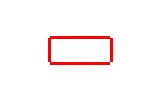

The red border above uses an explicit #FF0000 color on a constructed PathwayResult.


In [8]:
display(
    Image(filename=str(RESULTS / "evidence" / "03-highlight-hex-working.png"))
)
print("The red border above uses an explicit #FF0000 color on a constructed PathwayResult.")

## 6. Two silent-data examples

These deserve attention because they can produce a result without an obvious
crash:

- a numeric string such as `"10"` is interpreted as hexadecimal 16 instead of
  decimal 10;
- the Catmull-Rom function returns non-finite values for its documented normal
  example.

In [9]:
numeric = json.loads(
    (RESULTS / "evidence" / "04-numeric-reproductions.json").read_text()
)
for key, value in numeric.items():
    print(f"{key}: {value}")

decimal_10_color: #BF4040
string_10_interpreted_as_hex_color: #E51919
colors_match: False
catmull_rom_shape: [30, 2]
catmull_rom_all_finite: False
catmull_rom_nonfinite_values: 40


## 7. External services are a separate category

The default suite does not depend on the internet. Controlled request/response
tests confirm local URL construction and parsing behavior. Live observations
are kept separate because KEGG, Reactome, MyGene, BioCyc, or SMPDB can change or
be temporarily unavailable without a code change.

On the audit date, the officially documented KEGG organism-list URL returned
HTTP 400, while the official documentation still listed it. That currently
blocks normal non-`ko` calls because species resolution happens before the
cache check. See `EXTERNAL-SERVICE-OBSERVATIONS.md` for exact sources and the
current integration notes.

## 8. Files to send to the development team

- `PATHVIEW-BUG-CHECKS.md` — short, plain-language handoff.
- `TECHNICAL-FINDINGS.md` — prioritized details and source locations.
- `BUGS.json` — every reproduced finding and its exact test.
- `FEATURE-TEST-MATRIX.csv` — coverage by feature area.
- `results/audit-results.csv` — all individual test outcomes.
- `results/pytest-output.txt` — complete test log.
- `results/evidence/` — visual files and frozen pathway artifacts.

To rerun from this folder:

```bash
../pygage-pathview-validation/.venv/bin/python scripts/run_deep_checks.py
```